Exercício 1

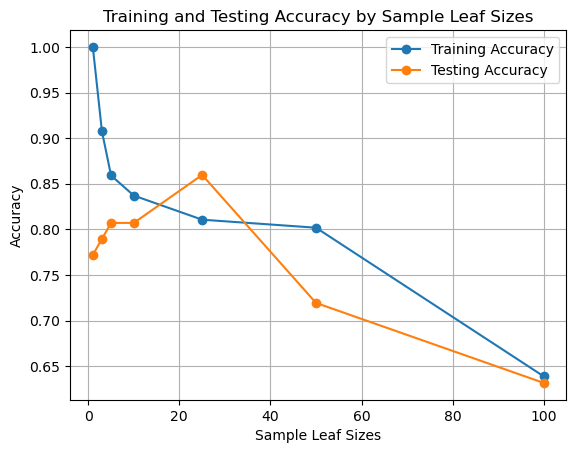

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

hhd = pd.read_csv("hungarian_heart_diseases.csv")
X, y = hhd.drop('outcome', axis=1), hhd['outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=1)

sample_leaf_sizes = [1, 3, 5, 10, 25, 50, 100]
training_accuracies = []
testing_accuracies = []

for leaf_size in sample_leaf_sizes: 
    classifier = DecisionTreeClassifier(min_samples_leaf=leaf_size, random_state=1)
    classifier.fit(X_train, y_train)

    training_accuracies.append(classifier.score(X_train, y_train))
    testing_accuracies.append(classifier.score(X_test, y_test))

plt.plot(sample_leaf_sizes, training_accuracies, label="Training Accuracy", marker='o')
plt.plot(sample_leaf_sizes, testing_accuracies, label="Testing Accuracy", marker='o')
plt.xlabel("Sample Leaf Sizes")
plt.ylabel("Accuracy")
plt.title("Training and Testing Accuracy by Sample Leaf Sizes")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.6, stratify=y, random_state=1)
X_test, X_validation, y_test, y_validation = train_test_split(X_temp, y_temp, train_size=0.5, stratify=y_temp, random_state=1)

best_accuracies = (0,0)
clf = None
for depth in range(2,5):
    for split in range(2,101): 
        classifier = DecisionTreeClassifier(max_depth=depth, min_samples_split=split, random_state=1)
        classifier.fit(X_train, y_train)

        t_acc = classifier.score(X_test, y_test)
        v_acc = classifier.score(X_validation, y_validation)
        
        if t_acc >= 0.785 and v_acc >= 0.8 and ((t_acc+v_acc) > (best_accuracies[0]+best_accuracies[1])):
            clf = classifier
            best_accuracies = (t_acc, v_acc)
    
if clf == None:
    print("No model fits parameters.")
else:
    plt.figure(figsize=(22,12))
    print("="*50)
    print(" Best Decision Tree Model ")
    print("="*50)
    print(f"Max depth         : {clf.min_samples_split}")
    print(f"Min samples split : {clf.min_samples_split}")
    print(f"Validation Acc.   : {best_accuracies[1]*100:.1f}%")
    print(f"Test Acc.         : {best_accuracies[0]*100:.1f}%")
    print("="*50, "\n")
    plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["Normal", "Heart Disease"],
    filled=True,
    rounded=True,
    fontsize=10,
    )
    plt.show()


No model fits parameters.
